# Week 5: Feature Extraction

**Goals:** Extract a 192-dimensional fixed-length feature vector from each audio file,
split into train/test sets (stratified), apply `StandardScaler` (fit on train only),
and save all outputs

**Feature vector breakdown (192 total):**
| Group | Dims | Description |
|---|---|---|
| MFCCs | 52 | 13 coefficients × {mean, std, min, max} |
| MFCC deltas | 52 | 13 × {mean, std, min, max} |
| Chroma STFT | 48 | 12 pitch classes × {mean, std, min, max} |
| Mel spectrogram | 20 | 20 mel bands, mean per band |
| ZCR | 4 | {mean, std, min, max} |
| RMS energy | 4 | {mean, std, min, max} |
| Spectral centroid | 4 | {mean, std, min, max} |
| Spectral bandwidth | 4 | {mean, std, min, max} |
| Spectral rolloff | 4 | {mean, std, min, max} |

## 1. Setup

In [26]:
import sys
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# Make SER_Project importable
sys.path.insert(0, str(pathlib.Path('../').resolve()))
from feature_extraction import extract_features, extract_all, get_feature_names, N_FEATURES

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

DATA_DIR    = pathlib.Path('../../data')
OUT_DIR     = pathlib.Path('../data')
FIGURES_DIR = pathlib.Path('../figures')
FIGURES_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

assert DATA_DIR.exists(), f'Data directory not found: {DATA_DIR.resolve()}'
print(f'Data:    {DATA_DIR.resolve()}')
print(f'Output:  {OUT_DIR.resolve()}')
print(f'Feature vector size: {N_FEATURES}')

Data:    C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\data
Output:  C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data
Feature vector size: 192


## 2. Load Metadata

In [27]:
meta = pd.read_csv(OUT_DIR / 'metadata.csv')

# Keep speech-only files (consistent with classification target)
meta = meta[meta['vocal_channel'] == 'speech'].reset_index(drop=True)

print(f'Speech files: {len(meta):,}')
print(f'Emotions:     {meta["emotion"].nunique()}')
meta.head(3)

Speech files: 1,440
Emotions:     8


,filepath,vocal_channel,emotion_id,emotion,intensity,actor_id,gender,duration_s,sample_rate,channels
0,..\..\data\Actor_01\03-01-01-01-01-01-01.wav,speech,1,neutral,normal,1,male,3.303292,48000,1
1,..\..\data\Actor_01\03-01-01-01-01-02-01.wav,speech,1,neutral,normal,1,male,3.336667,48000,1
2,..\..\data\Actor_01\03-01-01-01-02-01-01.wav,speech,1,neutral,normal,1,male,3.269917,48000,1


## 3. Feature Extraction

In [28]:
features_df = extract_all(meta, verbose=True)

print(f'Feature matrix: {features_df.shape}')
print(f'Any NaN: {features_df.isna().any().any()}')
features_df.head(2)

Extracting features: 100%|██████████| 1440/1440 [01:15<00:00, 18.97file/s]


Feature matrix: (1440, 192)
Any NaN: False


,mfcc_1_mean,mfcc_2_mean,mfcc_3_mean,mfcc_4_mean,mfcc_5_mean,mfcc_6_mean,mfcc_7_mean,mfcc_8_mean,mfcc_9_mean,mfcc_10_mean,...,centroid_min,centroid_max,bandwidth_mean,bandwidth_std,bandwidth_min,bandwidth_max,rolloff_mean,rolloff_std,rolloff_min,rolloff_max
0,-697.792603,54.890041,0.663465,12.435786,7.733951,0.530750,-3.216631,-3.159394,-10.977551,-2.848711,...,666.082687,7493.809847,2628.243580,746.399668,1181.364593,3561.051568,6330.385264,3002.907460,1044.360352,10174.438477
1,-692.855774,55.363899,-1.548319,16.038307,8.818810,-0.146586,-1.373392,-5.293180,-11.623182,-1.348284,...,697.654033,5318.545248,2675.836121,719.331209,1236.307024,3518.112543,6237.152100,2843.942963,1076.660156,9183.911133


## 4. Save Raw Features

In [29]:
# Attach metadata columns for convenience
full_df = pd.concat([
    meta[['filepath', 'emotion', 'emotion_id', 'actor_id', 'gender', 'intensity']].reset_index(drop=True),
    features_df.reset_index(drop=True),
], axis=1)

out_path = OUT_DIR / 'features.csv'
full_df.to_csv(out_path, index=False)
print(f'Saved features → {out_path.resolve()}  shape={full_df.shape}')

Saved features → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\features.csv  shape=(1440, 198)


## 5. Feature Visualisation

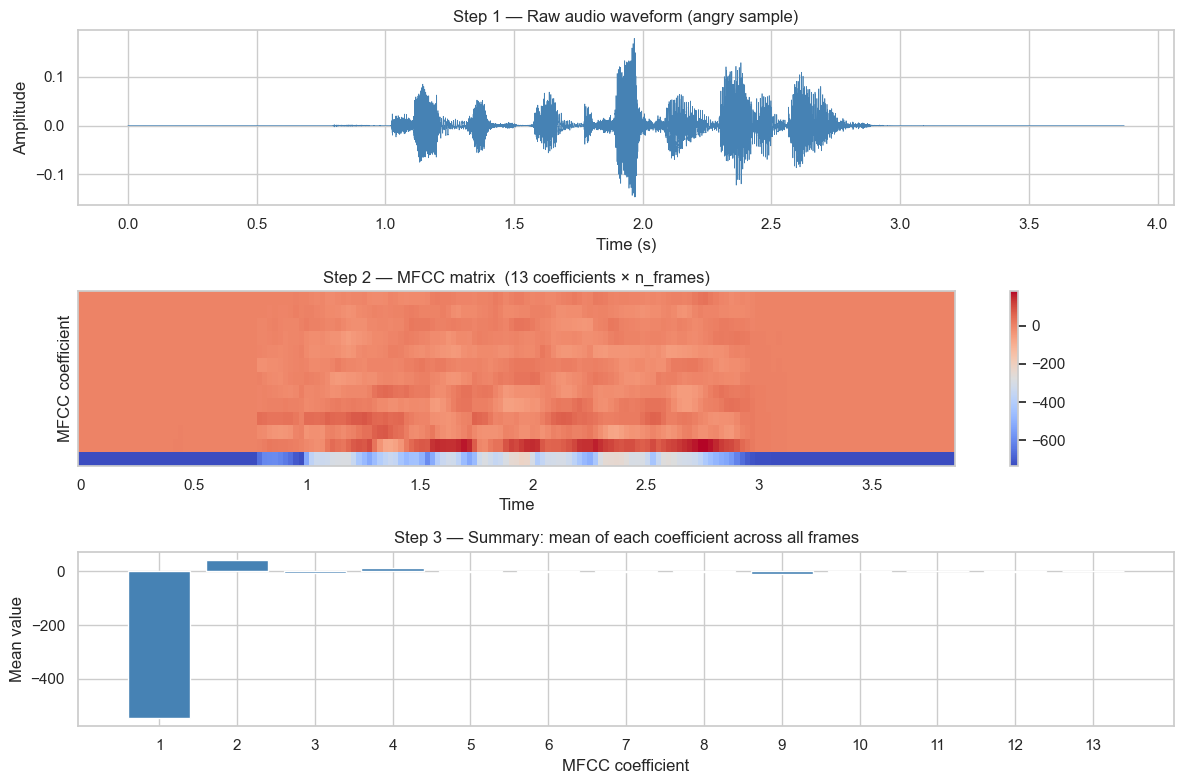

MFCC matrix shape: (13, 167)  →  summary shape: (13,)


In [30]:
### 5a. Pipeline walkthrough — one file
# Show what happens to a single audio file: waveform → MFCC matrix → summary vector

EMOTION_ORDER = ['neutral','calm','happy','sad','angry','fearful','disgust','surprised']

sample_row = meta[meta['emotion'] == 'angry'].iloc[0]
y, sr = librosa.load(sample_row['filepath'], sr=22050, mono=True)
mfcc  = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13, n_fft=2048, hop_length=512)

fig, axes = plt.subplots(3, 1, figsize=(12, 8))

# Row 1: raw waveform
t = np.linspace(0, len(y) / sr, len(y))
axes[0].plot(t, y, color='steelblue', linewidth=0.5)
axes[0].set(title='Step 1 — Raw audio waveform (angry sample)',
            xlabel='Time (s)', ylabel='Amplitude')

# Row 2: MFCC matrix (13 coefficients × ~170 frames)
librosa.display.specshow(mfcc, sr=sr, hop_length=512,
                         x_axis='time', ax=axes[1], cmap='coolwarm')
axes[1].set(title='Step 2 — MFCC matrix  (13 coefficients × n_frames)',
            ylabel='MFCC coefficient')
fig.colorbar(axes[1].collections[0], ax=axes[1])

# Row 3: mean of each MFCC coefficient (one number per row → the summary)
mfcc_means = mfcc.mean(axis=1)   # collapse time → 13 numbers
axes[2].bar(range(1, 14), mfcc_means, color='steelblue', edgecolor='white')
axes[2].set(title='Step 3 — Summary: mean of each coefficient across all frames',
            xlabel='MFCC coefficient', ylabel='Mean value')
axes[2].set_xticks(range(1, 14))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'pipeline_walkthrough.png', bbox_inches='tight')
plt.show()
print(f'MFCC matrix shape: {mfcc.shape}  →  summary shape: {mfcc_means.shape}')

### 5b. MFCC means by emotion heatmap

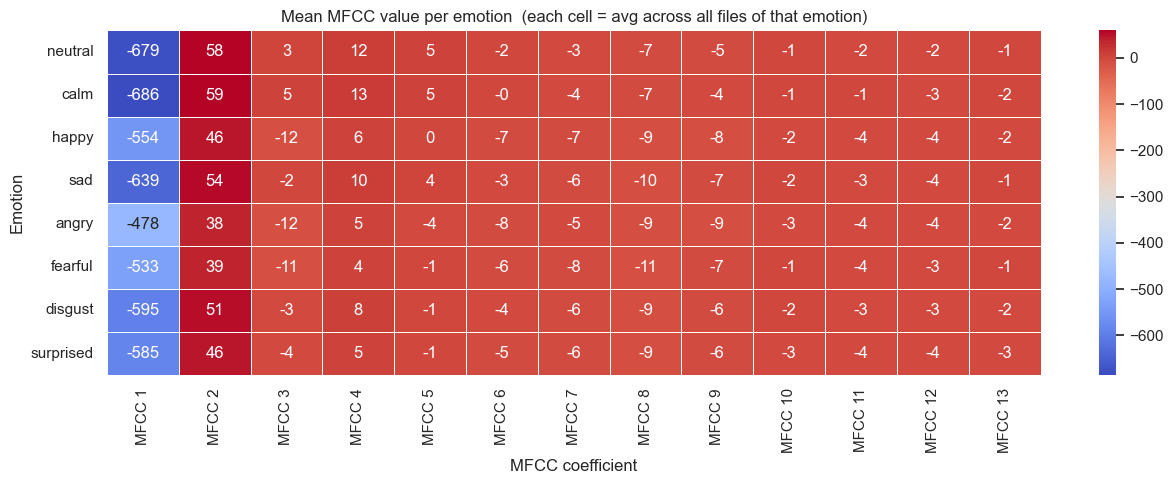

In [31]:
mfcc_mean_cols = [f'mfcc_{i}_mean' for i in range(1, 14)]

heatmap_df = (
    pd.concat([meta[['emotion']].reset_index(drop=True),
               features_df[mfcc_mean_cols].reset_index(drop=True)], axis=1)
    .groupby('emotion')[mfcc_mean_cols].mean()
    .reindex(EMOTION_ORDER)
)
heatmap_df.columns = [f'MFCC {i}' for i in range(1, 14)]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(heatmap_df, annot=True, fmt='.0f', cmap='coolwarm',
            linewidths=0.5, ax=ax)
ax.set(title='Mean MFCC value per emotion  (each cell = avg across all files of that emotion)',
       xlabel='MFCC coefficient', ylabel='Emotion')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'mfcc_by_emotion_heatmap.png', bbox_inches='tight')
plt.show()

**What to look for:**
- A column where all rows are the **same color** → that coefficient does not vary by emotion → not useful for classification
- A column where rows **vary in color** → that coefficient takes different values across emotions → useful for classification
- **MFCC 1** captures overall energy, so high-energy emotions (angry, fearful) visibly differ from calm/neutral
- Emotions that look **similar across all columns** (same color pattern) will be harder for a classifier to tell apart

### 5c. Energy and noisiness by emotion

C:\Users\zacha\AppData\Local\Temp\ipykernel_16628\1208691153.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='emotion', y='rms_mean', order=EMOTION_ORDER,
C:\Users\zacha\AppData\Local\Temp\ipykernel_16628\1208691153.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_df, x='emotion', y='zcr_mean', order=EMOTION_ORDER,


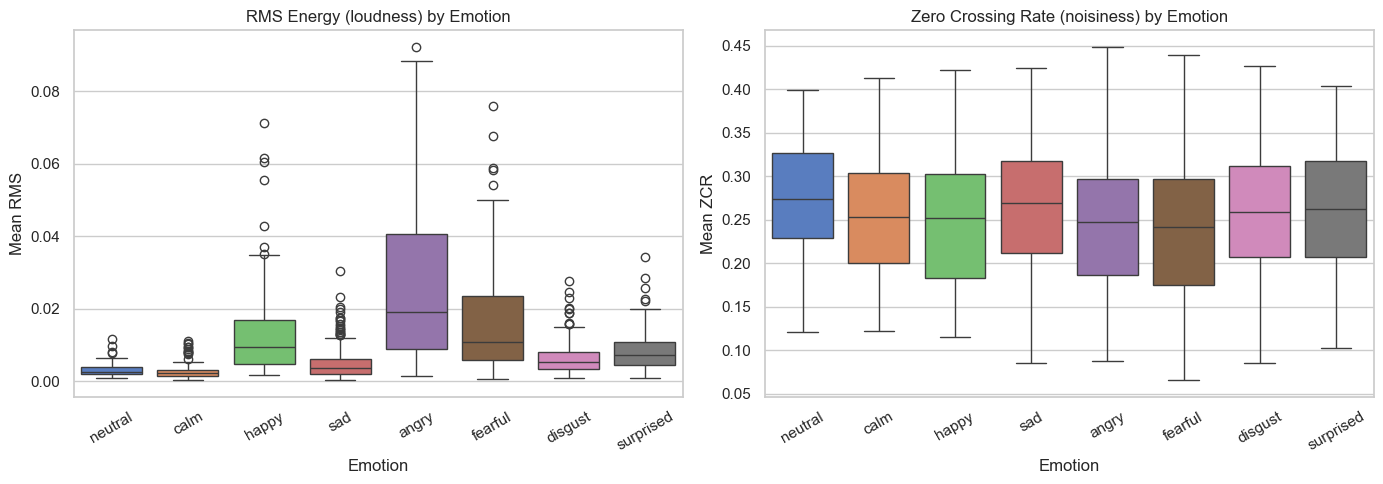

In [32]:
plot_df = pd.concat([
    meta[['emotion']].reset_index(drop=True),
    features_df[['rms_mean', 'zcr_mean']].reset_index(drop=True),
], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=plot_df, x='emotion', y='rms_mean', order=EMOTION_ORDER,
            palette='muted', ax=axes[0])
axes[0].set(title='RMS Energy (loudness) by Emotion', xlabel='Emotion', ylabel='Mean RMS')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=plot_df, x='emotion', y='zcr_mean', order=EMOTION_ORDER,
            palette='muted', ax=axes[1])
axes[1].set(title='Zero Crossing Rate (noisiness) by Emotion', xlabel='Emotion', ylabel='Mean ZCR')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'rms_zcr_by_emotion.png', bbox_inches='tight')
plt.show()

**RMS Energy** measures loudness: higher-energy emotions like angry and fearful tend to sit higher, while calm and neutral sit lower.

**Zero Crossing Rate** measures noisiness: how often the signal crosses zero per frame. Tense or breathy speech (fearful, angry) produces higher ZCR; smooth, controlled speech (calm, sad) produces lower ZCR.

These two features capture different axes of emotion: an emotion can be loud but smooth, or quiet but buzzy. No single feature separates all 8 emotions cleanly, which is why the full 192-feature vector is needed.

## 6. Stratified Train / Test Split

80 / 20 split, stratified by emotion label so every class is proportionally
represented in both sets.  Random seed fixed for reproducibility.

In [33]:
from sklearn.model_selection import train_test_split

X = features_df.values
y = meta['emotion_id'].values  # integer labels 1–8

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}   Test: {X_test.shape}')

# Verify stratification
unique, counts_tr = np.unique(y_train, return_counts=True)
_, counts_te      = np.unique(y_test,  return_counts=True)
strat_df = pd.DataFrame({
    'emotion_id': unique,
    'train': counts_tr,
    'test':  counts_te,
    'train%': (counts_tr / counts_tr.sum() * 100).round(1),
    'test%':  (counts_te / counts_te.sum() * 100).round(1),
})
print(strat_df.to_string(index=False))

Train: (1152, 192)   Test: (288, 192)
 emotion_id  train  test  train%  test%
          1     77    19     6.7    6.6
          2    154    38    13.4   13.2
          3    154    38    13.4   13.2
          4    154    38    13.4   13.2
          5    153    39    13.3   13.5
          6    153    39    13.3   13.5
          7    154    38    13.4   13.2
          8    153    39    13.3   13.5


## 7. Standardisation (StandardScaler)

Fit mean and standard deviation on **training data only**.
Apply the same transformation to the test set

In [34]:
# Manual StandardScaler (NumPy) — will be replaced by MiniLearn version later
train_mean = X_train.mean(axis=0)      # (192,)
train_std  = X_train.std(axis=0)       # (192,)

# Avoid divide-by-zero for constant features
train_std_safe = np.where(train_std == 0, 1.0, train_std)

X_train_scaled = (X_train - train_mean) / train_std_safe
X_test_scaled  = (X_test  - train_mean) / train_std_safe

print(f'Train scaled — mean: {X_train_scaled.mean():.4f},  std: {X_train_scaled.std():.4f}')
print(f'Test  scaled — mean: {X_test_scaled.mean():.4f},  std: {X_test_scaled.std():.4f}')

Train scaled — mean: 0.0000,  std: 0.9974
Test  scaled — mean: 0.0082,  std: 1.0598


## 8. Save Outputs

In [35]:
feat_names = get_feature_names()

pd.DataFrame(X_train_scaled, columns=feat_names).to_csv(
    OUT_DIR / 'X_train_scaled.csv', index=False)

pd.DataFrame(X_test_scaled, columns=feat_names).to_csv(
    OUT_DIR / 'X_test_scaled.csv', index=False)

pd.Series(y_train, name='emotion_id').to_csv(
    OUT_DIR / 'y_train.csv', index=False)

pd.Series(y_test, name='emotion_id').to_csv(
    OUT_DIR / 'y_test.csv', index=False)

# Scaler parameters (needed to inverse-transform or reuse in production)
pd.DataFrame({'feature': feat_names, 'mean': train_mean, 'std': train_std}).to_csv(
    OUT_DIR / 'scaler_params.csv', index=False)

for path in [
    'X_train_scaled.csv', 'X_test_scaled.csv',
    'y_train.csv', 'y_test.csv', 'scaler_params.csv'
]:
    p = OUT_DIR / path
    print(f'Saved {p.name:25s} → {p.resolve()}')

Saved X_train_scaled.csv        → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\X_train_scaled.csv
Saved X_test_scaled.csv         → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\X_test_scaled.csv
Saved y_train.csv               → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\y_train.csv
Saved y_test.csv                → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\y_test.csv
Saved scaler_params.csv         → C:\Users\zacha\OneDrive\Documents\miami\cse432\Project_CSE432-532\SER_Project\data\scaler_params.csv


**Output files:**

- **`features.csv`**: The raw (unscaled) feature matrix with metadata columns attached. Shape: 1440 rows × 198 columns (192 features + filepath, emotion, emotion_id, actor_id, gender, intensity). Used for reference and any analysis that doesn't require scaling.

- **`X_train_scaled.csv`**: The 1152 training samples after standardisation. Shape: 1152 × 192. This is what every classifier will train on.

- **`X_test_scaled.csv`**: The 288 test samples scaled using the training set's mean and std. Shape: 288 × 192. This is held out until evaluation — the model never sees it during training.

- **`y_train.csv`**: The emotion labels (integers 1–8) for the 1152 training samples. Paired row-for-row with `X_train_scaled.csv`.

- **`y_test.csv`**: The emotion labels for the 288 test samples. Paired row-for-row with `X_test_scaled.csv`.

- **`scaler_params.csv`**: The mean and std computed from the training set for each of the 192 features. Stored so the same scaling can be reapplied later without re-fitting (e.g., when predicting on a new file).

## 9. Summary

In [36]:
print('=== Week 5 Feature Extraction Summary ===')
print(f'  Total speech files processed : {len(meta):,}')
print(f'  Feature vector dimensionality: {N_FEATURES}')
print(f'  Train samples                : {X_train.shape[0]}')
print(f'  Test  samples                : {X_test.shape[0]}')
print(f'  Split ratio                  : 80/20 stratified')
print()
print('Output files:')
print('  data/features.csv       — raw features + metadata')
print('  data/X_train_scaled.csv — scaled training features')
print('  data/X_test_scaled.csv  — scaled test features')
print('  data/y_train.csv        — training labels')
print('  data/y_test.csv         — test labels')
print('  data/scaler_params.csv  — mean and std for each feature')

=== Week 5 Feature Extraction Summary ===
  Total speech files processed : 1,440
  Feature vector dimensionality: 192
  Train samples                : 1152
  Test  samples                : 288
  Split ratio                  : 80/20 stratified

Output files:
  data/features.csv       — raw features + metadata
  data/X_train_scaled.csv — scaled training features
  data/X_test_scaled.csv  — scaled test features
  data/y_train.csv        — training labels
  data/y_test.csv         — test labels
  data/scaler_params.csv  — mean and std for each feature


## 10. Discussion

**Why these features?**  MFCCs capture the timbral (vocal tract shape) information most
relevant to perceived emotion; their deltas capture temporal dynamics.  Chroma encodes
pitch class content, which varies with emotional prosody.  Mel spectrogram means provide a
compact energy distribution across the auditory frequency scale.  ZCR and RMS summarise
signal energy and voicing.  Spectral centroid, bandwidth and rolloff describe the
"brightness" and spread of the spectrum: features known to differ across affective states.

**Standardisation:** Fitting the scaler only on training data ensures that no information
from the test set leaks into the preprocessing step.  Features with zero variance (rare
constant features) are left unscaled to avoid division by zero.